# Using k-order Dynamic Bayesian Networks (k-TBN)

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F75-PyModels_KTBN.ipynb)

A **k-TBN** (k-order dynamic Bayesian network) generalizes the classical 2-TBN: instead of letting a variable at time $t$ depend on a single step backward, it lets it depend on up to the $k$ most recent time slices. A k-TBN is a *template* of $k$ consecutive slices; unrolling it for any horizon $T \geq k$ produces a plain `pyagrum.BayesNet`.

A k-TBN distinguishes two kinds of variables:
- **temporal** variables (processes), which evolve through time and have one instance per slice,
- **atemporal** variables, constant through time (e.g. a static context), which have a single instance.

(For more details see https://pyagrum.readthedocs.io/en/latest/ktbn.html)

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.ktbn as ktbn

## Building a k-TBN by hand

A small weather example: whether it `Rain`s and whether an `Umbrella` is carried depend on the previous time slice, and both depend on the (atemporal) `Season`. `Rain` and `Umbrella` are added as *temporal* processes (one instance per slice); `Season` is added as *atemporal* (a single instance, addressed with `ktbn.KTBN.ATEMPORAL`).

In [2]:
m = ktbn.KTBN(2)  # k=2: each variable depends on at most the previous slice

m.addTemporal(gum.LabelizedVariable("Rain", "raining?", ["no", "yes"]))
m.addTemporal(gum.LabelizedVariable("Umbrella", "umbrella carried?", ["no", "yes"]))
m.addAtemporal(gum.LabelizedVariable("Season", "season", ["dry", "wet"]))

m.addArc("Season", ktbn.KTBN.ATEMPORAL, "Rain", 0)
m.addArc("Season", ktbn.KTBN.ATEMPORAL, "Rain", 1)
m.addArc("Rain", 0, "Rain", 1)
m.addArc("Rain", 0, "Umbrella", 0)
m.addArc("Rain", 1, "Umbrella", 1)

print(m)

<pyagrum.ktbn.ktbncpp.KTBN; proxy of <Swig Object of type 'gum::KTBN< double > *' at 0x10ae76130> >


Nodes can be addressed either by an explicit `(base, slice)` pair, or by their *engine name* using bracket notation (`"Rain[1]"` for `Rain` at slice 1, a bare name like `"Season"` for an atemporal variable). Both spellings are accepted almost everywhere, including `toDot()`'s slice-clustered rendering below.

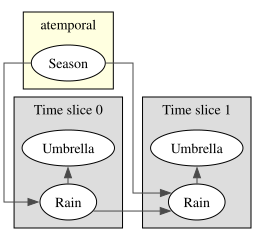

In [3]:
gnb.showDot(m.toDot())

`fillCPT` fills one conditional distribution at a time, addressing the node and its parents by name instead of by CPT positional order -- convenient once a k-TBN has more than a couple of parents per node. When the target node is given as `"base[slice]"`, parent keys can freely mix engine names and `(base, slice)` tuples; when the target is given as a `(base, slice)` pair instead, every parent key must also be a tuple.

In [4]:
m.fillCPT("Season", ktbn.KTBN.ATEMPORAL, {}, [0.5, 0.5])

m.fillCPT("Rain[0]", {"Season": "dry"}, [0.9, 0.1])
m.fillCPT("Rain[0]", {"Season": "wet"}, [0.4, 0.6])
m.fillCPT("Rain[1]", {"Rain[0]": "no", "Season": "dry"}, [0.8, 0.2])
m.fillCPT("Rain[1]", {"Rain[0]": "yes", "Season": "dry"}, [0.5, 0.5])
m.fillCPT("Rain[1]", {"Rain[0]": "no", "Season": "wet"}, [0.3, 0.7])
m.fillCPT("Rain[1]", {"Rain[0]": "yes", "Season": "wet"}, [0.1, 0.9])

m.fillCPT("Umbrella[0]", {"Rain[0]": "no"}, [0.9, 0.1])
m.fillCPT("Umbrella[0]", {"Rain[0]": "yes"}, [0.2, 0.8])
m.fillCPT("Umbrella[1]", {"Rain[1]": "no"}, [0.9, 0.1])
m.fillCPT("Umbrella[1]", {"Rain[1]": "yes"}, [0.2, 0.8])

The same fast-construction syntax as `pyagrum.fastBN` is available through `gum.fastVariable`, using bracket notation to declare a process's domain directly in its name (`"X[2]"`): `add()` clones it into `k` instances unless `temporal=False` is passed.

In [5]:
m2 = ktbn.KTBN(2)
m2.add(gum.fastVariable("X[2]"))         # temporal by default: X[0], X[1]
m2.add(gum.fastVariable("C"), False)     # atemporal
m2.addArc("X", 0, "X", 1)
m2.addArc("C", ktbn.KTBN.ATEMPORAL, "X", 0)
m2.generateCPTs()  # random CPTs, useful for quick experiments
print(m2)

<pyagrum.ktbn.ktbncpp.KTBN; proxy of <Swig Object of type 'gum::KTBN< double > *' at 0x10bb50f70> >


## Unrolling into a plain Bayesian network

`unroll(T)` expands the template into a standard `pyagrum.BayesNet` with exactly `T` time slices: slices `0..k-1` are copied verbatim, every later slice replicates the transition kernel (slice `k-1`). The result can be used with any of pyAgrum's usual BN inference engines.

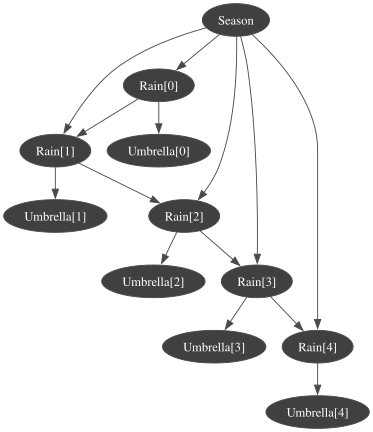

In [6]:
bn = m.unroll(5)
gnb.showBN(bn, size="6")

In [7]:
ie = gum.LazyPropagation(bn)
ie.makeInference()
ie.posterior("Rain[3]")

(pyagrum.Tensor@0x785acda520) 
  Rain[3]          │
no       │yes      │
─────────│─────────│
 0.4233  │ 0.5767  │

## Inference directly on the k-TBN

`KTBNInference` runs inference over the k-TBN template directly, without materializing the unrolled network. It supports hard/soft observations, `do`-interventions, and both are addressed the same way as everywhere else: `(base, slice)` or an engine name.

In [8]:
kie = ktbn.KTBNInference(m)
kie.addObservation("Season", "wet")
kie.addObservation("Rain", 0, "yes")
kie.makeInference(5)  # horizon: number of time slices to compute

kie.posterior("Rain", 3)

(pyagrum.Tensor@0x785a3b9248) 
  Rain[3]          │
no       │yes      │
─────────│─────────│
 0.1240  │ 0.8760  │

In [9]:
# the whole time series for one base variable, one Tensor per slice
series = kie.posteriors("Rain")
for t, p in enumerate(series):
    print(f"P(Rain[{t}] | Season=wet, Rain[0]=yes) =", p.tolist())

P(Rain[0] | Season=wet, Rain[0]=yes) = [0.0, 1.0]
P(Rain[1] | Season=wet, Rain[0]=yes) = [0.09999999999999998, 0.8999999999999999]
P(Rain[2] | Season=wet, Rain[0]=yes) = [0.11999999999999998, 0.8799999999999999]
P(Rain[3] | Season=wet, Rain[0]=yes) = [0.124, 0.8759999999999999]
P(Rain[4] | Season=wet, Rain[0]=yes) = [0.12480000000000002, 0.8752]


`addIntervention` sets a variable by `do(...)` instead of conditioning on it -- the causal semantics differ from an observation whenever the intervened variable has parents in the template.

In [10]:
kie2 = ktbn.KTBNInference(m)
kie2.addIntervention("Rain", 0, "yes")  # do(Rain[0] = yes), regardless of Season
kie2.makeInference(4)
kie2.posterior("Umbrella", 3)

(pyagrum.Tensor@0x7859881de8) 
  Umbrella[3]      │
no       │yes      │
─────────│─────────│
 0.4867  │ 0.5134  │

## Persistence

A k-TBN is saved/loaded through `save`/`load` (or the free functions `saveKTBN`/`loadKTBN`), in a text (`.jgum`) or binary (`.bgum`) GUM format selected by the file extension. Bracket-encoded engine names are preserved literally through the round-trip, including nested brackets such as `"X[0][2]"` for a fast-syntax process named `X[2]` at slice 0.

In [11]:
import tempfile, os

path = os.path.join(tempfile.mkdtemp(), "weather.bgum")
m.save(path)
reloaded = ktbn.loadKTBN(path)
print(reloaded.k(), reloaded.sizeArcs())

2 5


## Randomly generating a k-TBN

`KTBNGenerator` draws a random template -- variables, a legal arc set, and (optionally) random CPTs -- mainly to build ground-truth models for learning experiments: sample trajectories, learn the structure back, and compare.

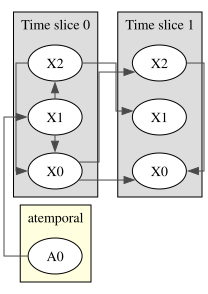

In [12]:
gum.initRandom(42)
gen = ktbn.KTBNGenerator(2, 3, 1)  # k=2, 3 temporal processes, 1 atemporal variable
gen.setDensity(0.4)
gm = gen.generate()
gm.generateCPTs()
gnb.showDot(gm.toDot())

## Sampling trajectories and learning a k-TBN back

Unlike a plain Bayesian network, a k-TBN describes a *process*: its database is a set of trajectories, one CSV file per trajectory, rather than a flat table of i.i.d. rows. `KTBNDatabaseGenerator` samples them by sliding the k-slice template forward in time.

In [15]:
dbgen = ktbn.KTBNDatabaseGenerator(gm)
outdir = tempfile.mkdtemp()
dbgen.drawSamples(5, 12, outdir, "traj")  # 5 trajectories of length 12

(-22.731959282802382,
 -30.543438157723696,
 -23.15433945608443,
 -31.593623285652733,
 -37.7086896944281)

`KTBNLearner` learns the order-`k` structure and parameters back from the trajectories. Domains are inferred from the first trajectory by default, which is unsafe for atemporal columns (constant within a trajectory, so only one label ever shows up in file 1): supplying a schema `BayesNet` with the full domains sidesteps that.

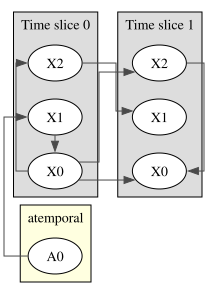

In [16]:
dbgen.drawSamples(200, 100, outdir, "traj")  # 200 trajectories of length 100

schema = gum.BayesNet()
for name in list(gm.temporalVarNames()) + list(gm.atemporalVarNames()):
    schema.add(gum.LabelizedVariable(name, "", ["0", "1"]))

learner = ktbn.KTBNLearner(outdir, "traj", 200, 2, schema, gm.atemporalVarNames())
learner.useScoreBIC().useGreedyHillClimbing()
learned = learner.learnKTBN()
gnb.showDot(learned.toDot())

When the order $k$ itself is unknown, `KTBNAdaptiveLearner` explores every candidate in `[2, kMax]`, learns one k-TBN per candidate, and keeps the one with the best cross-$k$ model-selection score (BIC by default).

In [18]:
adaptive = ktbn.KTBNAdaptiveLearner(outdir, "traj", 200, 5, schema, gm.atemporalVarNames())
adaptive.useScoreBIC().useGreedyHillClimbing()
best = adaptive.learnKTBN()
print("selected k :", adaptive.bestK())
print("score per candidate k :", adaptive.scorePerCandidateK())

selected k : 2
score per candidate k : ((2, -41364.55483828359), (3, -41415.17441679913), (4, -41449.40902781305), (5, -41490.60516992296))
